# V3: GAT + Threshold-based ER — Анализ результатов

Визуализация результатов экспериментов 08–11:
1. **Эксп. 08** — статистика объединённого графа
2. **Эксп. 09** — кривые обучения GAT (NT-Xent)
3. **Эксп. 10** — оценка: threshold-based F1/P/R (production-like)
4. **Эксп. 11** — BCE ablation: сравнение NT-Xent vs BCE

Pipeline оценки (как в production):
- Val pairs → оптимальный порог θ (max F1 по cosine similarity)
- Test pairs → F1, Precision, Recall @ θ + ROC-AUC, AP
- Cross-domain → те же метрики с тем же порогом (generalization)

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import torch

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../output")
UNIFIED_DIR = DATA_DIR / "graphs" / "v3_unified"
CROSS_DIR = DATA_DIR / "graphs" / "v3_cross"

---
## 1. Статистика объединённого графа (Эксп. 08)

In [2]:
with open(UNIFIED_DIR / "stats.json") as f:
    stats = json.load(f)

print(f"Датасетов:       {stats['n_datasets']}")
print(f"Строк (row):     {stats['n_rows']:,}")
print(f"Токенов (token): {stats['n_tokens']:,}")
print(f"Рёбер:           {stats['n_edges']:,}")
print(f"Labeled pairs:   {stats['n_labeled']:,}")
print(f"  train:         {stats['n_train']:,} ({100*stats['n_train']/stats['n_labeled']:.1f}%)")
print(f"  val:           {stats['n_val']:,} ({100*stats['n_val']/stats['n_labeled']:.1f}%)")
print(f"  test:          {stats['n_test']:,} ({100*stats['n_test']/stats['n_labeled']:.1f}%)")
print(f"\nДатасеты: {', '.join(stats['datasets'])}")

# Shared tokens: токены, связанные с 2+ уникальными строками (после IDF-фильтрации)
graph = torch.load(UNIFIED_DIR / "graph.pt", weights_only=False)
t2r_edge_index = graph["token", "in_row", "row"].edge_index
token_ids = t2r_edge_index[0]  # source = token
row_ids = t2r_edge_index[1]    # target = row
n_tokens_graph = graph["token"].x.shape[0]
n_edges_total = t2r_edge_index.shape[1]

# Уникальные пары (token, row) — убираем дубли рёбер если есть
pairs = torch.stack([token_ids, row_ids], dim=1)
unique_pairs = pairs.unique(dim=0)
unique_token_ids = unique_pairs[:, 0]

# Количество уникальных строк на токен
token_row_count = torch.zeros(n_tokens_graph, dtype=torch.long)
token_row_count.scatter_add_(0, unique_token_ids, torch.ones_like(unique_token_ids))

shared_mask = token_row_count >= 2
n_shared = shared_mask.sum().item()
# Рёбра от shared токенов
edge_from_shared = shared_mask[token_ids].sum().item()
max_rows = token_row_count.max().item()
mean_shared = token_row_count[shared_mask].float().mean().item() if n_shared > 0 else 0

print(f"\n--- Shared tokens (после IDF-фильтрации) ---")
print(f"Всего токенов:         {n_tokens_graph:,}")
print(f"Shared (в 2+ строках): {n_shared:,} ({100*n_shared/n_tokens_graph:.1f}%)")
print(f"Рёбер от shared:       {edge_from_shared:,} ({100*edge_from_shared/n_edges_total:.1f}% от всех)")
print(f"Макс. строк на токен:  {max_rows}")
print(f"Среднее строк (shared):{mean_shared:.1f}")
del graph

Датасетов:       21
Строк (row):     341,053
Токенов (token): 19,087
Рёбер:           6,022,885
Labeled pairs:   6,797
  train:         4,758 (70.0%)
  val:           1,020 (15.0%)
  test:          1,019 (15.0%)

Датасеты: baby_products, beer, bikes, books1, books2, books3, books4, books5, cosmetics, ebooks1, ebooks2, movies1, movies2, movies3, movies4, movies5, music, restaurants1, restaurants2, restaurants3, restaurants4


c:\Users\olegk\Desktop\ДИПЛОМ\СуперДиплом\TableUnifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- Shared tokens (после IDF-фильтрации) ---
Всего токенов:         19,087
Shared (в 2+ строках): 18,914 (99.1%)
Рёбер от shared:       6,022,705 (100.0% от всех)
Макс. строк на токен:  3383
Среднее строк (shared):290.8


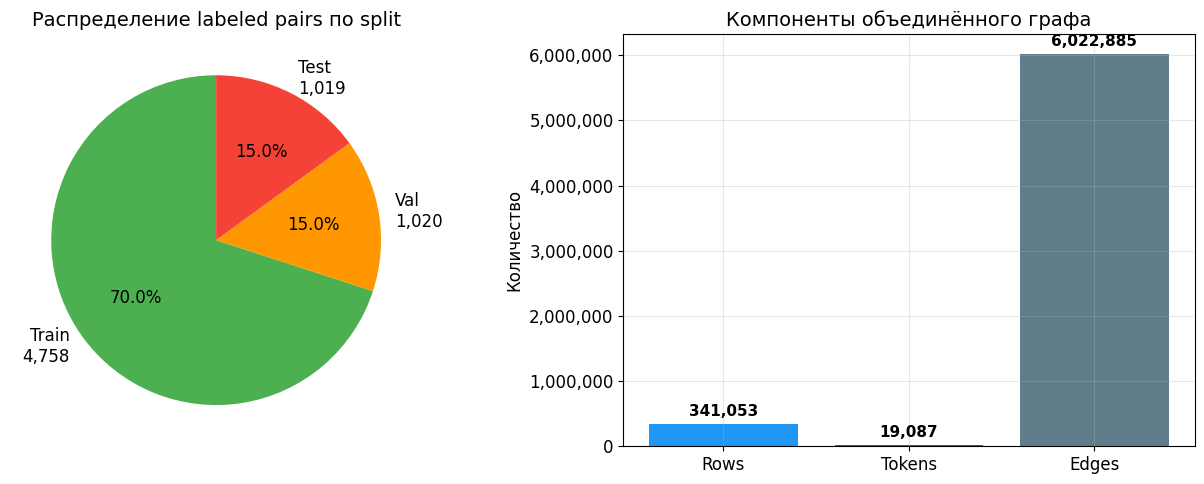

In [3]:
# Распределение split
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie: split proportions
split_sizes = [stats["n_train"], stats["n_val"], stats["n_test"]]
split_labels = [f"Train\n{stats['n_train']:,}", f"Val\n{stats['n_val']:,}", f"Test\n{stats['n_test']:,}"]
colors = ["#4CAF50", "#FF9800", "#F44336"]
axes[0].pie(split_sizes, labels=split_labels, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 12})
axes[0].set_title("Распределение labeled pairs по split", fontsize=14)

# Bar: graph components
components = ["Rows", "Tokens", "Edges"]
values = [stats["n_rows"], stats["n_tokens"], stats["n_edges"]]
bars = axes[1].bar(components, values, color=["#2196F3", "#9C27B0", "#607D8B"])
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
                f"{val:,}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Компоненты объединённого графа", fontsize=14)
axes[1].set_ylabel("Количество")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "v3_graph_stats.png", dpi=150, bbox_inches="tight")
plt.show()

IDF порог:            1.0% (3,410 строк)
Токенов до / после:   20,268 → 19,087 (удалено 1,073, 5.3%)
Рёбер до фильтрации:  24,306,686
  − IDF-фильтрация:   −14,699,890 (60.5%)
  = после IDF:         9,606,796
  − per-cell лимит:    −3,583,911 (14.7%)
  = финальных рёбер:   6,022,885 (24.8% от исходных)


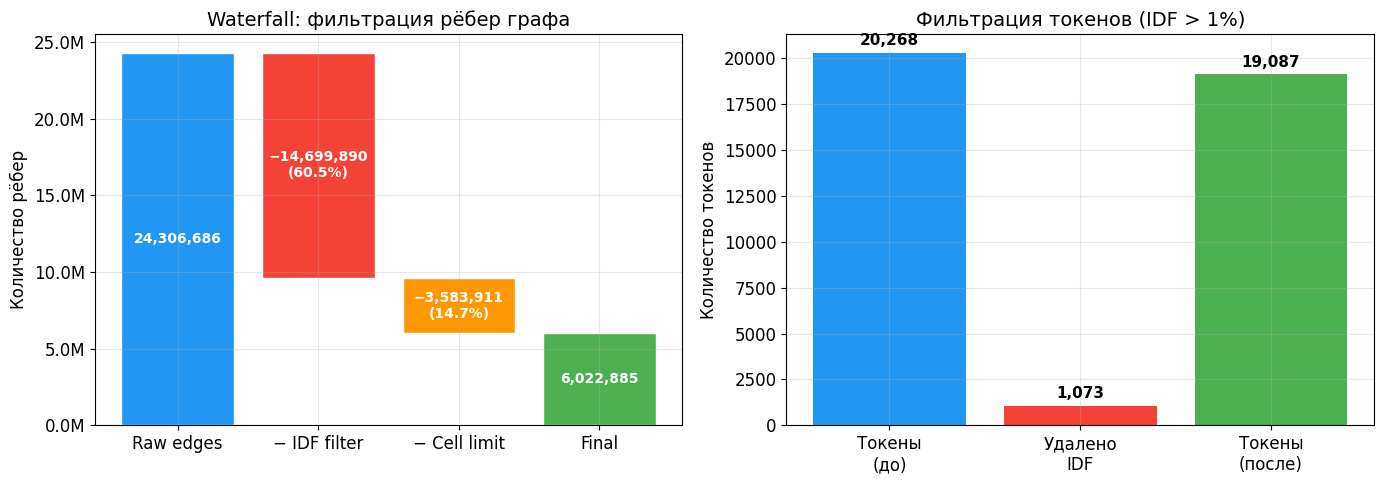

In [4]:
# Эффект IDF-фильтрации и per-cell лимита на рёбра
fs = stats.get("filter_stats", {})
if fs:
    raw_e = fs["raw_edges"]
    removed_idf = fs["edges_removed_idf"]
    after_idf = fs["edges_after_idf"]
    removed_cell = fs["edges_removed_cell_limit"]
    final_e = fs["final_edges"]

    print(f"IDF порог:            {fs['idf_threshold']:.1%} ({int(fs['idf_threshold'] * stats['n_rows']):,} строк)")
    print(f"Токенов до / после:   {fs['raw_tokens']:,} → {fs['final_tokens']:,} "
          f"(удалено {fs['tokens_removed_idf']:,}, {100*fs['tokens_removed_idf']/fs['raw_tokens']:.1f}%)")
    print(f"Рёбер до фильтрации:  {raw_e:,}")
    print(f"  − IDF-фильтрация:   −{removed_idf:,} ({100*removed_idf/raw_e:.1f}%)")
    print(f"  = после IDF:         {after_idf:,}")
    print(f"  − per-cell лимит:    −{removed_cell:,} ({100*removed_cell/raw_e:.1f}%)")
    print(f"  = финальных рёбер:   {final_e:,} ({100*final_e/raw_e:.1f}% от исходных)")

    # Waterfall chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: waterfall — поэтапное уменьшение рёбер
    ax = axes[0]
    stages = ["Raw edges", "− IDF filter", "− Cell limit", "Final"]
    values = [raw_e, -removed_idf, -removed_cell, final_e]
    cumulative = [raw_e, after_idf, final_e, final_e]
    bottoms = [0, final_e + removed_cell, final_e, 0]

    colors_wf = ["#2196F3", "#F44336", "#FF9800", "#4CAF50"]
    bars = ax.bar(stages, [abs(v) for v in values], bottom=bottoms, color=colors_wf, edgecolor="white")

    for bar, val, cum in zip(bars, values, cumulative):
        y = bar.get_y() + bar.get_height() / 2
        label = f"{abs(val):,.0f}"
        if val < 0:
            label = f"−{abs(val):,.0f}\n({100*abs(val)/raw_e:.1f}%)"
        ax.text(bar.get_x() + bar.get_width()/2, y, label,
                ha="center", va="center", fontsize=10, fontweight="bold", color="white")

    ax.set_ylabel("Количество рёбер")
    ax.set_title("Waterfall: фильтрация рёбер графа", fontsize=14)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

    # Right: token filtering — before/after
    ax = axes[1]
    tok_labels = ["Токены\n(до)", "Удалено\nIDF", "Токены\n(после)"]
    tok_vals = [fs["raw_tokens"], fs["tokens_removed_idf"], fs["final_tokens"]]
    tok_colors = ["#2196F3", "#F44336", "#4CAF50"]
    bars = ax.bar(tok_labels, tok_vals, color=tok_colors)
    for bar, val in zip(bars, tok_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(tok_vals)*0.02,
                f"{val:,}", ha="center", fontsize=11, fontweight="bold")
    ax.set_ylabel("Количество токенов")
    ax.set_title(f"Фильтрация токенов (IDF > {fs['idf_threshold']:.0%})", fontsize=14)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "v3_filtering_stats.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("filter_stats отсутствует в stats.json — перезапустите эксперимент 08")

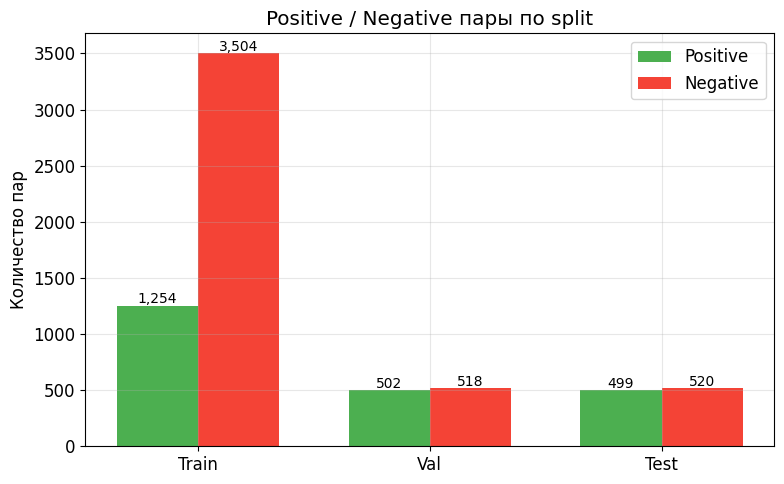

Train : 4,758 пар, 1254 pos (26.4%), 3504 neg
Val   : 1,020 пар, 502 pos (49.2%), 518 neg
Test  : 1,019 пар, 499 pos (49.0%), 520 neg


In [5]:
# Распределение pos/neg в каждом split
train_pairs = torch.load(UNIFIED_DIR / "train_pairs.pt", weights_only=False)
val_pairs = torch.load(UNIFIED_DIR / "val_pairs.pt", weights_only=False)
test_pairs = torch.load(UNIFIED_DIR / "test_pairs.pt", weights_only=False)

splits = {"Train": train_pairs, "Val": val_pairs, "Test": test_pairs}
pos_counts = {name: int((p[:, 2] == 1).sum()) for name, p in splits.items()}
neg_counts = {name: int((p[:, 2] == 0).sum()) for name, p in splits.items()}

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(splits))
w = 0.35
bars1 = ax.bar(x - w/2, pos_counts.values(), w, label="Positive", color="#4CAF50")
bars2 = ax.bar(x + w/2, neg_counts.values(), w, label="Negative", color="#F44336")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f"{int(bar.get_height()):,}", ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(splits.keys())
ax.set_ylabel("Количество пар")
ax.set_title("Positive / Negative пары по split")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "v3_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

for name, p in splits.items():
    pos = int((p[:, 2] == 1).sum())
    print(f"{name:6s}: {len(p):,} пар, {pos} pos ({100*pos/len(p):.1f}%), {len(p)-pos} neg")

---
## 2. Кривые обучения GAT модели (Эксп. 09)

In [6]:
history_path = OUTPUT_DIR / "v3_gat_model.history.json"
with open(history_path) as f:
    history = json.load(f)

epochs = list(range(1, len(history["train_loss"]) + 1))
print(f"Эпох обучения: {len(epochs)}")
print(f"Финальный train_loss: {history['train_loss'][-1]:.4f}")
if history["val_loss"]:
    best_val_idx = int(np.argmin(history["val_loss"]))
    print(f"Лучший val_loss:     {history['val_loss'][best_val_idx]:.4f} (эпоха {best_val_idx + 1})")
if history.get("lr"):
    print(f"Финальный LR:        {history['lr'][-1]:.2e}")

Эпох обучения: 56
Финальный train_loss: 0.9443
Лучший val_loss:     1.3527 (эпоха 36)
Финальный LR:        7.50e-04


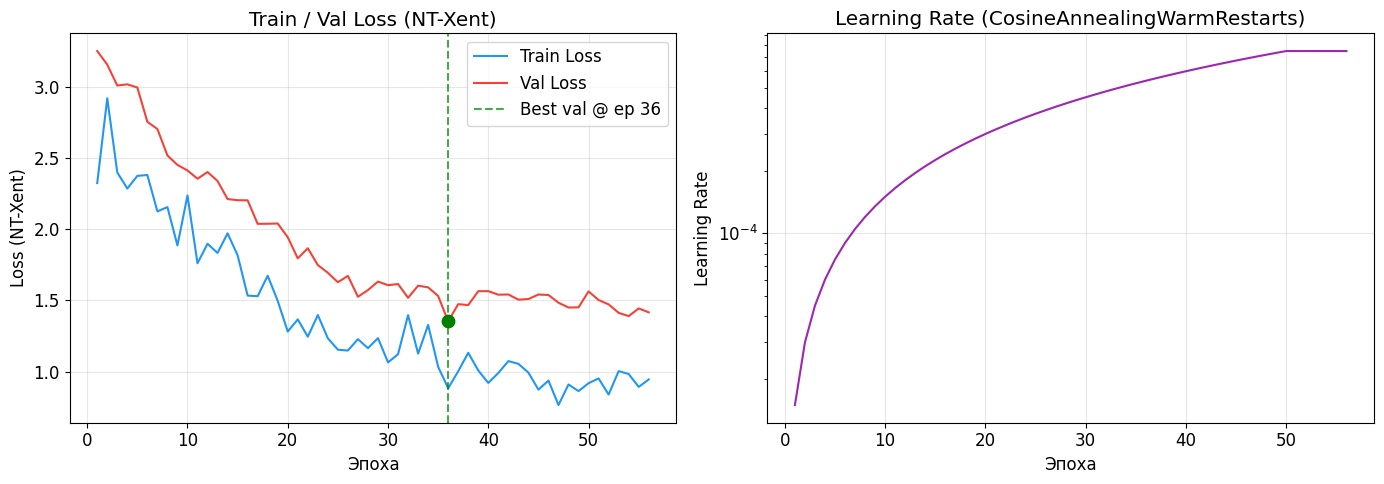

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curves ---
ax = axes[0]
ax.plot(epochs, history["train_loss"], label="Train Loss", color="#2196F3", linewidth=1.5)
if history["val_loss"]:
    val_epochs = list(range(1, len(history["val_loss"]) + 1))
    ax.plot(val_epochs, history["val_loss"], label="Val Loss", color="#F44336", linewidth=1.5)
    best_val_idx = int(np.argmin(history["val_loss"]))
    ax.axvline(best_val_idx + 1, color="green", linestyle="--", alpha=0.7,
               label=f"Best val @ ep {best_val_idx + 1}")
    ax.scatter([best_val_idx + 1], [history["val_loss"][best_val_idx]],
              color="green", s=80, zorder=5)

ax.set_xlabel("Эпоха")
ax.set_ylabel("Loss (NT-Xent)")
ax.set_title("Train / Val Loss (NT-Xent)")
ax.legend()

# --- Learning rate ---
ax = axes[1]
if history.get("lr"):
    lr_epochs = list(range(1, len(history["lr"]) + 1))
    ax.plot(lr_epochs, history["lr"], color="#9C27B0", linewidth=1.5)
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Learning Rate")
    ax.set_title("Learning Rate (CosineAnnealingWarmRestarts)")
    ax.set_yscale("log")
else:
    ax.text(0.5, 0.5, "LR history not available", transform=ax.transAxes, ha="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "v3_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

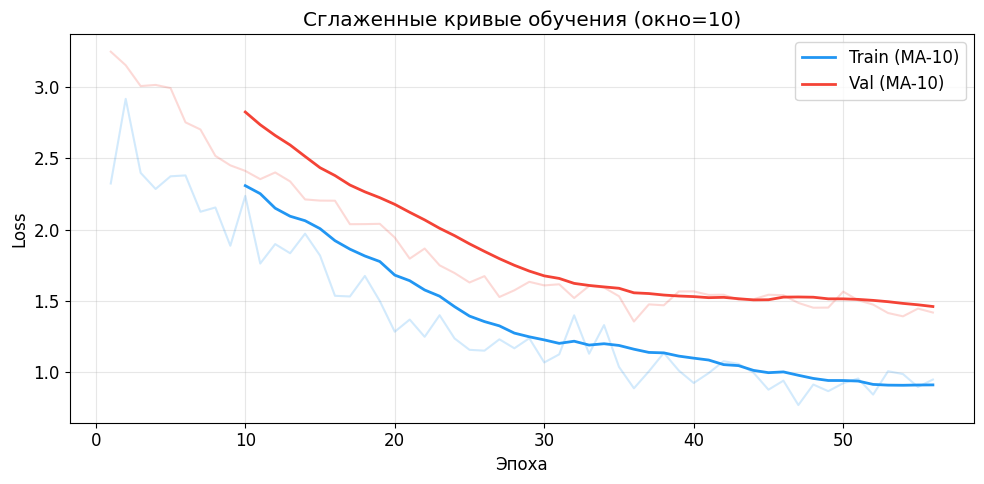

In [8]:
# Smoothed loss (скользящее среднее)
def smooth(values, window=10):
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

fig, ax = plt.subplots(figsize=(10, 5))

window = min(10, len(epochs) // 5) if len(epochs) > 20 else 3
sm_train = smooth(history["train_loss"], window)
sm_epochs = list(range(window, len(history["train_loss"]) + 1))

ax.plot(epochs, history["train_loss"], alpha=0.2, color="#2196F3")
ax.plot(sm_epochs, sm_train, label=f"Train (MA-{window})", color="#2196F3", linewidth=2)

if history["val_loss"]:
    sm_val = smooth(history["val_loss"], window)
    val_epochs_all = list(range(1, len(history["val_loss"]) + 1))
    sm_val_epochs = list(range(window, len(history["val_loss"]) + 1))
    ax.plot(val_epochs_all, history["val_loss"], alpha=0.2, color="#F44336")
    ax.plot(sm_val_epochs, sm_val, label=f"Val (MA-{window})", color="#F44336", linewidth=2)

ax.set_xlabel("Эпоха")
ax.set_ylabel("Loss")
ax.set_title(f"Сглаженные кривые обучения (окно={window})")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "v3_training_curves_smooth.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Результаты оценки — Threshold-based (Эксп. 10)

Production pipeline: cosine similarity → порог θ → match/no-match.  
Порог подобран на val (max F1), применён к test и cross-domain.

In [9]:
with open(OUTPUT_DIR / "v3_evaluation_results.json") as f:
    results = json.load(f)

threshold = results["threshold"]
print(f"Оптимальный порог θ = {threshold:.4f}")
print()

print("=" * 55)
print("VAL (подбор порога)")
print("=" * 55)
if results.get("val"):
    for k, v in results["val"].items():
        if isinstance(v, float):
            print(f"  {k:20s}: {v:.4f}")
        else:
            print(f"  {k:20s}: {v}")

print()
print("=" * 55)
print("TEST (held-out)")
print("=" * 55)
if results.get("test"):
    for k, v in results["test"].items():
        if isinstance(v, float):
            print(f"  {k:20s}: {v:.4f}")
        else:
            print(f"  {k:20s}: {v}")

print()
print("=" * 55)
print("CROSS-DOMAIN (тот же порог)")
print("=" * 55)
for r in results.get("cross_domain", []):
    f1 = r.get("f1", "N/A")
    f1s = f"{f1:.4f}" if isinstance(f1, float) else f1
    p = r.get("precision", "N/A")
    ps = f"{p:.4f}" if isinstance(p, float) else p
    rec = r.get("recall", "N/A")
    rs = f"{rec:.4f}" if isinstance(rec, float) else rec
    auc = r.get("roc_auc", "N/A")
    aucs = f"{auc:.4f}" if isinstance(auc, float) else auc
    print(f"  {r['name']:15s}  F1={f1s}  P={ps}  R={rs}  AUC={aucs}")

Оптимальный порог θ = 0.7683

VAL (подбор порога)
  threshold           : 0.7683
  f1                  : 0.8525
  precision           : 0.8648
  recall              : 0.8406
  n_pairs             : 1020
  n_pos               : 502
  n_predicted_pos     : 488
  roc_auc             : 0.9143
  avg_precision       : 0.9202

TEST (held-out)
  threshold           : 0.7683
  f1                  : 0.8436
  precision           : 0.8668
  recall              : 0.8216
  n_pairs             : 1019
  n_pos               : 499
  n_predicted_pos     : 473
  roc_auc             : 0.9219
  avg_precision       : 0.9249

CROSS-DOMAIN (тот же порог)
  anime            F1=0.3077  P=1.0000  R=0.1818  AUC=0.9873
  citations        F1=0.0000  P=0.0000  R=0.0000  AUC=0.5540
  electronics      F1=0.0370  P=1.0000  R=0.0189  AUC=0.9091


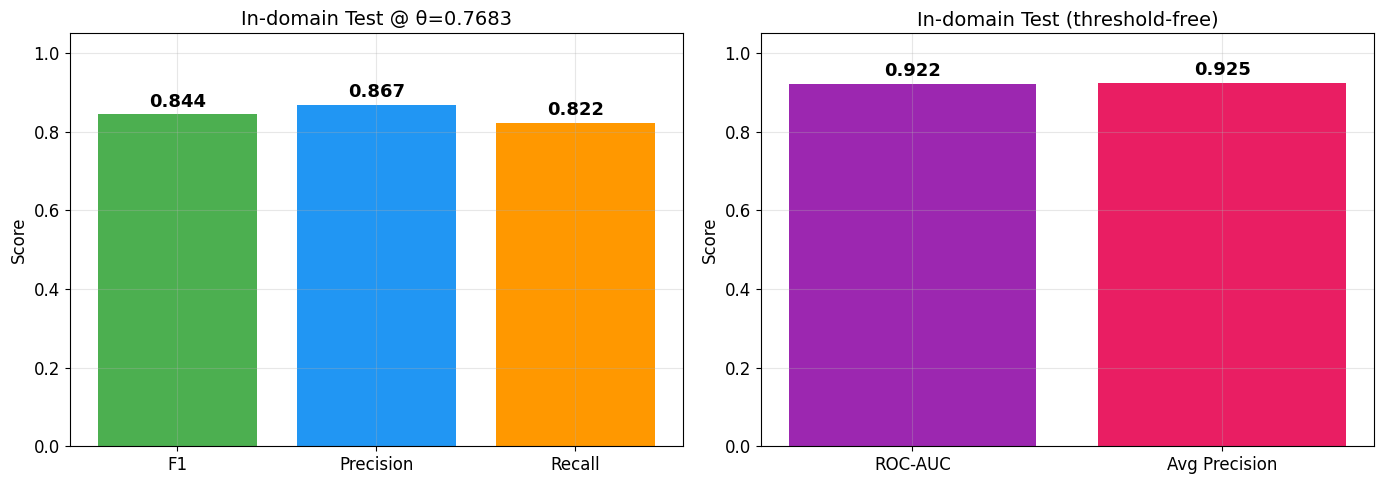

In [10]:
# --- In-domain: F1 / Precision / Recall + ROC-AUC / AP ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

test = results.get("test", {})

# Bar 1: F1, Precision, Recall
ax = axes[0]
metrics_names = ["F1", "Precision", "Recall"]
metrics_vals = [test.get("f1", 0), test.get("precision", 0), test.get("recall", 0)]
colors_bar = ["#4CAF50", "#2196F3", "#FF9800"]
bars = ax.bar(metrics_names, metrics_vals, color=colors_bar)
for bar, val in zip(bars, metrics_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_title(f"In-domain Test @ θ={threshold:.4f}", fontsize=14)
ax.set_ylabel("Score")

# Bar 2: ROC-AUC, AP
ax = axes[1]
auc_names = ["ROC-AUC", "Avg Precision"]
auc_vals = [test.get("roc_auc", 0), test.get("avg_precision", 0)]
colors_auc = ["#9C27B0", "#E91E63"]
bars = ax.bar(auc_names, auc_vals, color=colors_auc)
for bar, val in zip(bars, auc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_title("In-domain Test (threshold-free)", fontsize=14)
ax.set_ylabel("Score")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "v3_in_domain_results.png", dpi=150, bbox_inches="tight")
plt.show()

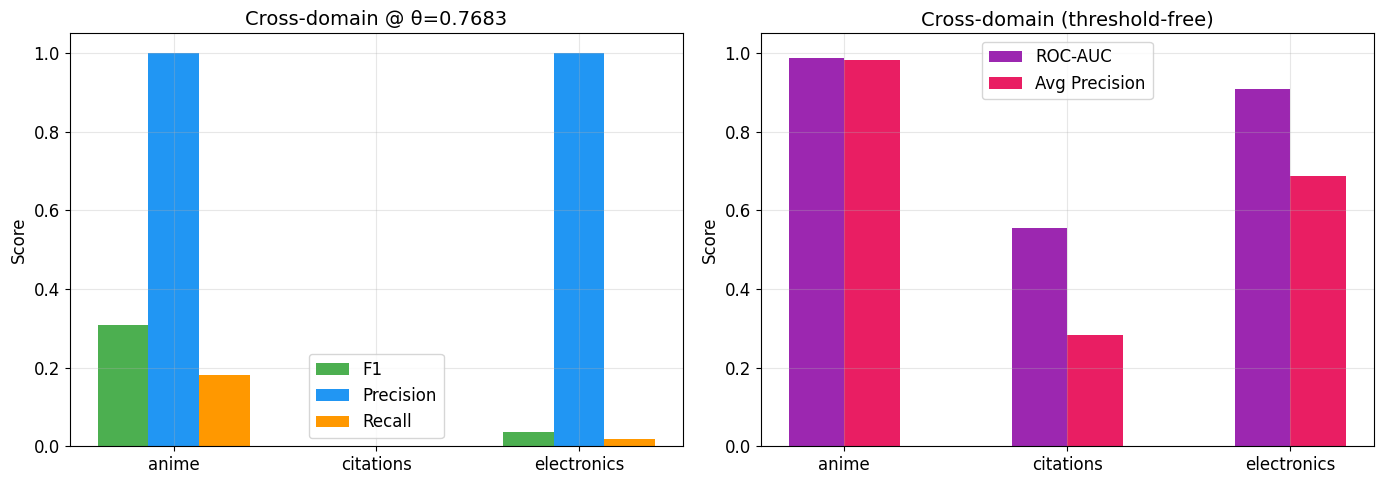

In [11]:
# --- Cross-domain: F1 + ROC-AUC grouped bar ---
cross = results.get("cross_domain", [])
if cross:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    names = [r["name"] for r in cross]
    f1s = [r.get("f1", 0) for r in cross]
    precs = [r.get("precision", 0) for r in cross]
    recs = [r.get("recall", 0) for r in cross]
    aucs = [r.get("roc_auc", 0) for r in cross]
    aps = [r.get("avg_precision", 0) for r in cross]

    # F1 / P / R
    ax = axes[0]
    x = np.arange(len(names))
    w = 0.25
    b1 = ax.bar(x - w, f1s, w, label="F1", color="#4CAF50")
    b2 = ax.bar(x, precs, w, label="Precision", color="#2196F3")
    b3 = ax.bar(x + w, recs, w, label="Recall", color="#FF9800")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Cross-domain @ θ={threshold:.4f}", fontsize=14)
    ax.legend()
    ax.set_ylabel("Score")

    # ROC-AUC / AP
    ax = axes[1]
    b1 = ax.bar(x - w/2, aucs, w, label="ROC-AUC", color="#9C27B0")
    b2 = ax.bar(x + w/2, aps, w, label="Avg Precision", color="#E91E63")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 1.05)
    ax.set_title("Cross-domain (threshold-free)", fontsize=14)
    ax.legend()
    ax.set_ylabel("Score")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "v3_cross_domain_results.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## 4. Сводная таблица

In [12]:
import pandas as pd

rows = []

# Val
if results.get("val"):
    row = {"Dataset": "VAL (threshold selection)", "Type": "in-domain"}
    row.update({k: v for k, v in results["val"].items() if isinstance(v, (int, float))})
    rows.append(row)

# Test
if results.get("test"):
    row = {"Dataset": "TEST (held-out)", "Type": "in-domain"}
    row.update({k: v for k, v in results["test"].items() if isinstance(v, (int, float))})
    rows.append(row)

# Cross-domain
for r in results.get("cross_domain", []):
    row = {"Dataset": r["name"], "Type": "cross-domain"}
    row.update({k: v for k, v in r.items() if k != "name" and isinstance(v, (int, float))})
    rows.append(row)

df = pd.DataFrame(rows)
display_cols = ["Dataset", "Type", "f1", "precision", "recall", "roc_auc", "avg_precision"]
display_cols = [c for c in display_cols if c in df.columns]
print(f"Порог θ = {threshold:.4f}\n")
df[display_cols]

Порог θ = 0.7683



,Dataset,Type,f1,precision,recall,roc_auc,avg_precision
0,VAL (threshold selection),in-domain,0.852525,0.864754,0.840637,0.914250,0.920191
1,TEST (held-out),in-domain,0.843621,0.866808,0.821643,0.921932,0.924905
2,anime,cross-domain,0.307692,1.000000,0.181818,0.987330,0.982813
3,citations,cross-domain,0.000000,0.000000,0.000000,0.554031,0.282946
4,electronics,cross-domain,0.037037,1.000000,0.018868,0.909107,0.687521


---
## 5. Распределение эмбеддингов (t-SNE)

In [13]:
from sklearn.manifold import TSNE
from table_unifier.config import Config, EntityResolutionConfig
from table_unifier.models.entity_resolution import EntityResolutionGAT, PairClassifier
from table_unifier.training.er_trainer import get_row_embeddings

# Загрузка конфигурации: HPO если есть, иначе defaults
hpo_arch_path = OUTPUT_DIR / "hpo_architecture.json"
hpo_train_path = OUTPUT_DIR / "hpo_training.json"

if hpo_arch_path.exists() and hpo_train_path.exists():
    with open(hpo_arch_path) as f:
        best_arch = json.load(f)["best_params"]
    with open(hpo_train_path) as f:
        best_training = json.load(f)["best_training"]
    ER_CONFIG = EntityResolutionConfig(
        hidden_dim=best_arch["hidden_dim"],
        edge_dim=best_arch["edge_dim"],
        num_gnn_layers=best_arch["num_gnn_layers"],
        dropout=best_arch["dropout"],
        bidirectional=best_arch["bidirectional"],
        num_heads=4, attention_dropout=0.1,
        temperature=0.1,
    )
    print(f"Конфигурация из HPO: {best_arch['num_gnn_layers']} layers, hidden={best_arch['hidden_dim']}")
else:
    ER_CONFIG = EntityResolutionConfig(
        hidden_dim=128, edge_dim=128, num_gnn_layers=2,
        dropout=0.3, bidirectional=True,
        num_heads=4, attention_dropout=0.1,
        temperature=0.1,
    )
    print("Конфигурация по умолчанию: 2 layers, hidden=128")


def load_model_and_embeddings(graph, model_path, device="cpu", bce=False):
    """Загрузить модель и получить эмбеддинги."""
    cfg = ER_CONFIG
    cfg.row_dim = int(graph["row"].x.shape[1])
    cfg.token_dim = int(graph["token"].x.shape[1])
    cfg.col_dim = int(graph.col_embeddings.shape[1])

    backbone = EntityResolutionGAT(
        row_dim=cfg.row_dim, token_dim=cfg.token_dim, col_dim=cfg.col_dim,
        hidden_dim=cfg.hidden_dim, edge_dim=cfg.edge_dim, output_dim=cfg.output_dim,
        num_gnn_layers=cfg.num_gnn_layers, num_heads=cfg.num_heads,
        dropout=cfg.dropout, attention_dropout=cfg.attention_dropout,
        bidirectional=cfg.bidirectional,
    )

    if bce:
        model = PairClassifier(backbone, embedding_dim=cfg.output_dim)
        state = torch.load(model_path, map_location=device, weights_only=True)
        model.load_state_dict(state)
        return get_row_embeddings(model.backbone, graph, device=device)
    else:
        state = torch.load(model_path, map_location=device, weights_only=True)
        backbone.load_state_dict(state)
        return get_row_embeddings(backbone, graph, device=device)

Конфигурация из HPO: 3 layers, hidden=128


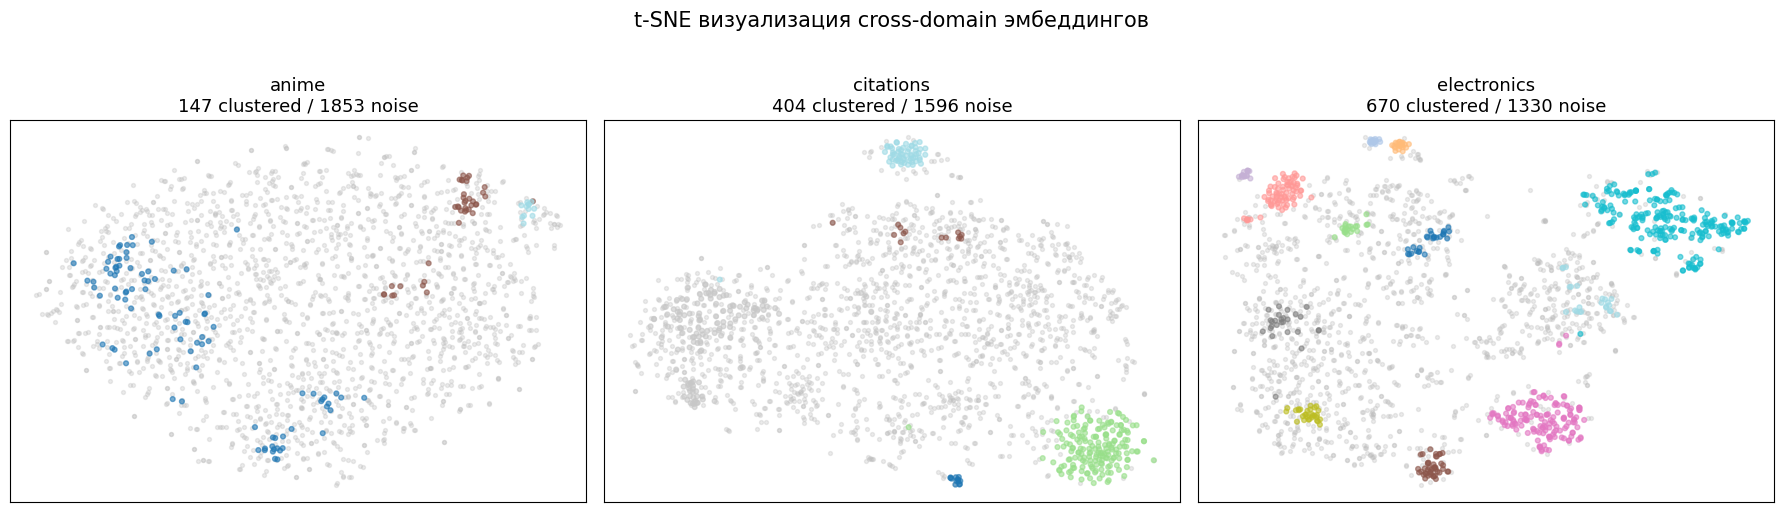

In [14]:
# t-SNE для cross-domain датасетов
model_path = OUTPUT_DIR / "v3_gat_model.pt"
cross_dirs = sorted([d for d in CROSS_DIR.iterdir() if d.is_dir() and (d / "graph.pt").exists()])

if cross_dirs:
    n_plots = len(cross_dirs)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    for ax, ds_dir in zip(axes, cross_dirs):
        name = ds_dir.name
        graph = torch.load(ds_dir / "graph.pt", weights_only=False)
        emb = load_model_and_embeddings(graph, model_path)

        # Subsample for speed
        n = min(2000, len(emb))
        idx = np.random.choice(len(emb), n, replace=False)
        emb_sub = emb[idx].numpy()

        tsne = TSNE(n_components=2, perplexity=30, random_state=42)
        proj = tsne.fit_transform(emb_sub)

        # Раскраска: HDBSCAN кластеры
        from table_unifier.evaluation.clustering import cluster_embeddings
        labels = cluster_embeddings(emb[idx], min_cluster_size=10)

        noise_mask = labels == -1
        ax.scatter(proj[noise_mask, 0], proj[noise_mask, 1],
                   c="#BDBDBD", s=8, alpha=0.3, label="noise")
        ax.scatter(proj[~noise_mask, 0], proj[~noise_mask, 1],
                   c=labels[~noise_mask], cmap="tab20", s=12, alpha=0.6)
        ax.set_title(f"{name}\n{(~noise_mask).sum()} clustered / {noise_mask.sum()} noise", fontsize=13)
        ax.set_xticks([])
        ax.set_yticks([])

        del graph, emb
        torch.cuda.empty_cache()

    plt.suptitle("t-SNE визуализация cross-domain эмбеддингов", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "v3_tsne_cross_domain.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Cross-domain графы не найдены")

---
## 6. Ablation: NT-Xent vs BCE

In [15]:
from pathlib import Path

saved = list(OUTPUT_DIR.glob("v3_*.png"))
print(f"Сохранено {len(saved)} графиков в {OUTPUT_DIR}:")
for p in sorted(saved):
    print(f"  {p.name}")

Сохранено 12 графиков в ..\output:
  v3_ablation_cross_domain.png
  v3_ablation_in_domain.png
  v3_ablation_metrics.png
  v3_ablation_training.png
  v3_cross_domain_results.png
  v3_filtering_stats.png
  v3_graph_stats.png
  v3_in_domain_results.png
  v3_split_distribution.png
  v3_training_curves.png
  v3_training_curves_smooth.png
  v3_tsne_cross_domain.png


In [16]:
# Загрузка результатов обоих экспериментов
ntxent_results_path = OUTPUT_DIR / "v3_evaluation_results.json"
bce_results_path = OUTPUT_DIR / "v3_evaluation_results_bce.json"

has_ntxent = ntxent_results_path.exists()
has_bce = bce_results_path.exists()

if has_ntxent:
    with open(ntxent_results_path) as f:
        ntxent_results = json.load(f)
if has_bce:
    with open(bce_results_path) as f:
        bce_results = json.load(f)

if has_ntxent and has_bce:
    print(f"NT-Xent порог: {ntxent_results['threshold']:.4f}")
    print(f"BCE порог:     {bce_results['threshold']:.4f}")
elif has_ntxent:
    print("Только NT-Xent результаты доступны")
elif has_bce:
    print("Только BCE результаты доступны")
else:
    print("Нет результатов для сравнения")

NT-Xent порог: 0.7683
BCE порог:     0.5341


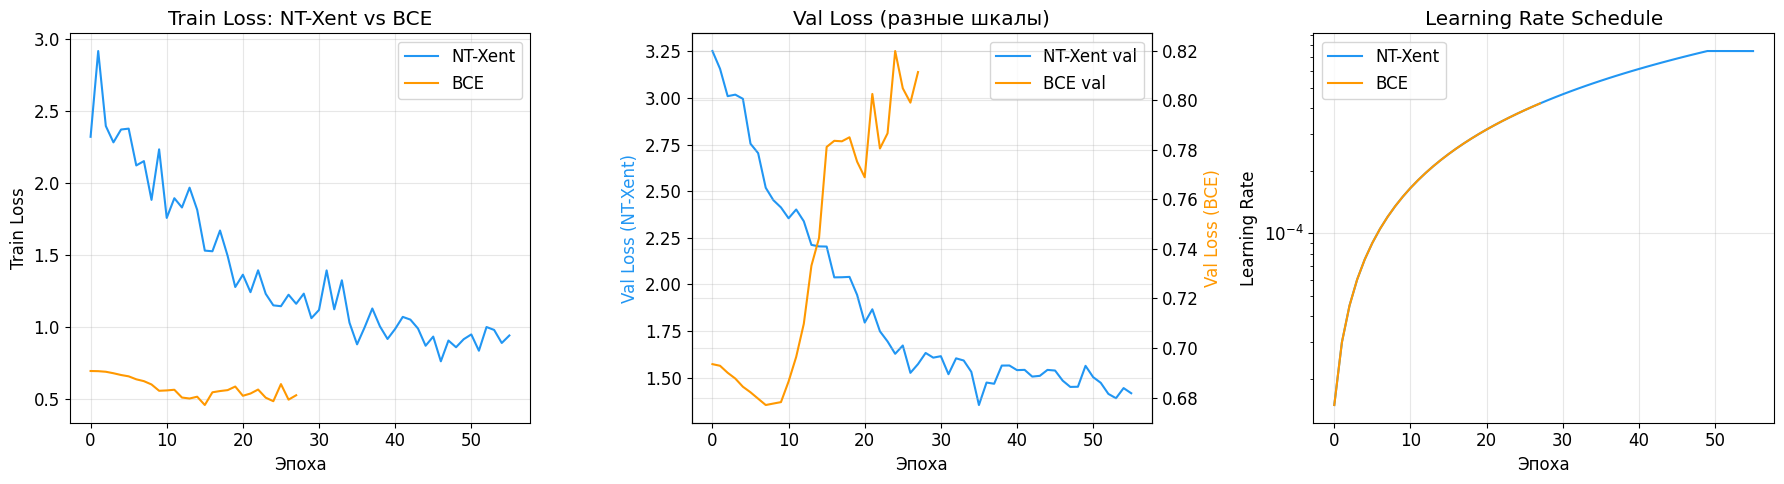

NT-Xent: 56 эпох, best val=1.3527
BCE:     28 эпох, best val=0.6770


In [17]:
# 6.1 Сравнение кривых обучения NT-Xent vs BCE
ntxent_hist_path = OUTPUT_DIR / "v3_gat_model.history.json"
bce_hist_path = OUTPUT_DIR / "v3_gat_bce_model.history.json"

if ntxent_hist_path.exists() and bce_hist_path.exists():
    with open(ntxent_hist_path) as f:
        h_ntxent = json.load(f)
    with open(bce_hist_path) as f:
        h_bce = json.load(f)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Train loss
    ax = axes[0]
    ax.plot(h_ntxent["train_loss"], label="NT-Xent", color="#2196F3", linewidth=1.5)
    ax.plot(h_bce["train_loss"], label="BCE", color="#FF9800", linewidth=1.5)
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Train Loss")
    ax.set_title("Train Loss: NT-Xent vs BCE")
    ax.legend()

    # Val loss (разные шкалы — два y-axis)
    ax = axes[1]
    if h_ntxent["val_loss"] and h_bce["val_loss"]:
        ax.plot(h_ntxent["val_loss"], label="NT-Xent val", color="#2196F3", linewidth=1.5)
        ax2 = ax.twinx()
        ax2.plot(h_bce["val_loss"], label="BCE val", color="#FF9800", linewidth=1.5)
        ax.set_xlabel("Эпоха")
        ax.set_ylabel("Val Loss (NT-Xent)", color="#2196F3")
        ax2.set_ylabel("Val Loss (BCE)", color="#FF9800")
        ax.set_title("Val Loss (разные шкалы)")

        # Combined legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2)

    # LR comparison
    ax = axes[2]
    if h_ntxent.get("lr") and h_bce.get("lr"):
        ax.plot(h_ntxent["lr"], label="NT-Xent", color="#2196F3", linewidth=1.5)
        ax.plot(h_bce["lr"], label="BCE", color="#FF9800", linewidth=1.5)
        ax.set_xlabel("Эпоха")
        ax.set_ylabel("Learning Rate")
        ax.set_title("Learning Rate Schedule")
        ax.set_yscale("log")
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "v3_ablation_training.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Stats
    print(f"NT-Xent: {len(h_ntxent['train_loss'])} эпох, "
          f"best val={min(h_ntxent['val_loss']):.4f}" if h_ntxent["val_loss"] else "")
    print(f"BCE:     {len(h_bce['train_loss'])} эпох, "
          f"best val={min(h_bce['val_loss']):.4f}" if h_bce["val_loss"] else "")
else:
    missing = []
    if not ntxent_hist_path.exists():
        missing.append("NT-Xent (эксп. 09)")
    if not bce_hist_path.exists():
        missing.append("BCE (эксп. 11)")
    print(f"Не хватает истории обучения: {', '.join(missing)}")

ABLATION: In-domain Test



,Threshold,F1,Precision,Recall,ROC-AUC,Avg Precision
Method,,,,,,
NT-Xent,0.768300,0.843621,0.866808,0.821643,0.921932,0.924905
BCE,0.534113,0.760591,0.748062,0.773547,0.834315,0.843440


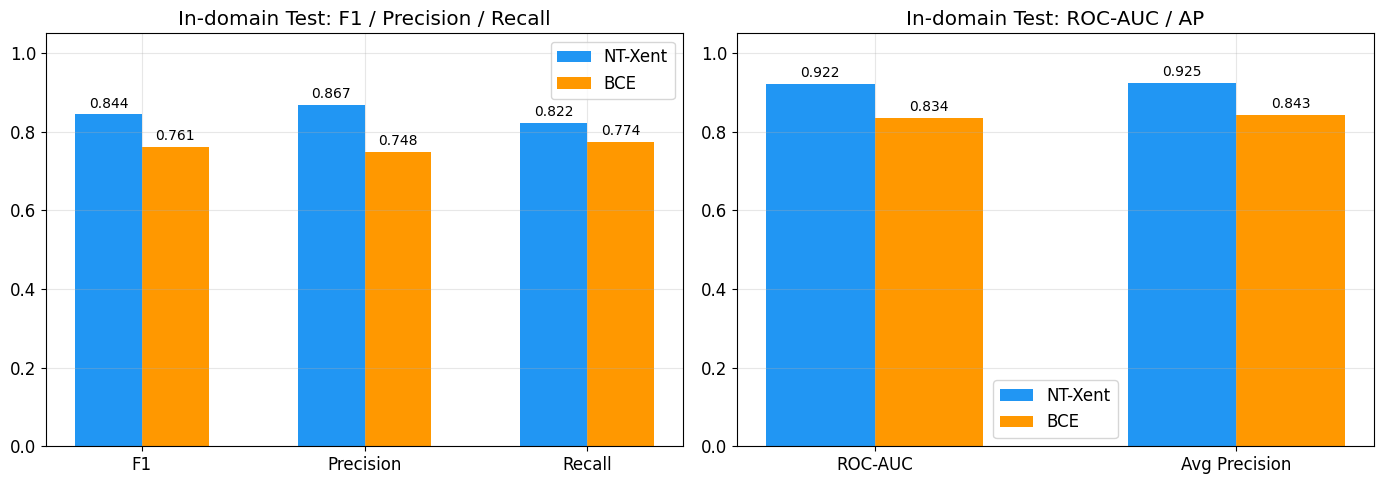

In [18]:
# 6.2 Ablation: In-domain Test — NT-Xent vs BCE
if has_ntxent and has_bce:
    import pandas as pd

    methods = {"NT-Xent": ntxent_results, "BCE": bce_results}
    rows = []
    for method, res in methods.items():
        row = {"Method": method, "Threshold": res.get("threshold")}
        if res.get("test"):
            t = res["test"]
            row["F1"] = t.get("f1")
            row["Precision"] = t.get("precision")
            row["Recall"] = t.get("recall")
            row["ROC-AUC"] = t.get("roc_auc")
            row["Avg Precision"] = t.get("avg_precision")
        rows.append(row)

    df_ablation = pd.DataFrame(rows).set_index("Method")
    print("=" * 60)
    print("ABLATION: In-domain Test")
    print("=" * 60)
    print()
    display(df_ablation)

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # F1 / P / R
    ax = axes[0]
    metrics = ["F1", "Precision", "Recall"]
    x = np.arange(len(metrics))
    w = 0.3
    for i, (method, color) in enumerate([("NT-Xent", "#2196F3"), ("BCE", "#FF9800")]):
        vals = [df_ablation.loc[method, m] for m in metrics]
        bars = ax.bar(x + i * w - w/2, vals, w, label=method, color=color)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_title("In-domain Test: F1 / Precision / Recall")

    # ROC-AUC / AP
    ax = axes[1]
    metrics2 = ["ROC-AUC", "Avg Precision"]
    x2 = np.arange(len(metrics2))
    for i, (method, color) in enumerate([("NT-Xent", "#2196F3"), ("BCE", "#FF9800")]):
        vals = [df_ablation.loc[method, m] for m in metrics2]
        bars = ax.bar(x2 + i * w - w/2, vals, w, label=method, color=color)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=10)
    ax.set_xticks(x2)
    ax.set_xticklabels(metrics2)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_title("In-domain Test: ROC-AUC / AP")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "v3_ablation_in_domain.png", dpi=150, bbox_inches="tight")
    plt.show()

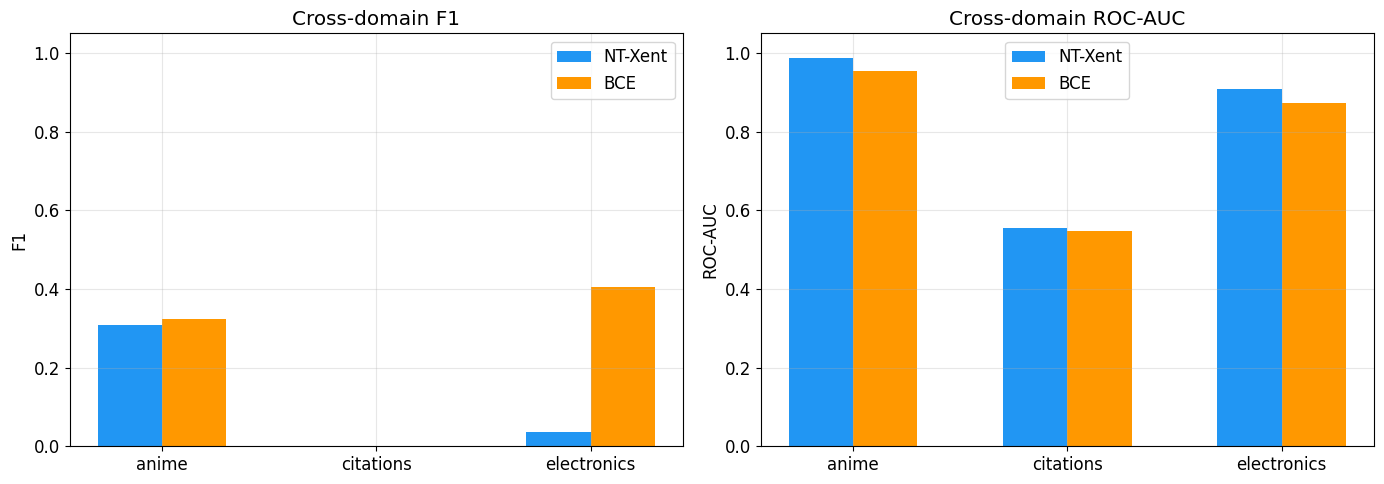

,NT-Xent F1,NT-Xent AUC,BCE F1,BCE AUC
Dataset,,,,
anime,0.3077,0.9873,0.3243,0.9547
citations,0.0000,0.5540,0.0000,0.5466
electronics,0.0370,0.9091,0.4058,0.8741


In [19]:
# 6.3 Cross-domain ablation: F1 comparison
if has_ntxent and has_bce:
    cross_nt = {r["name"]: r for r in ntxent_results.get("cross_domain", [])}
    cross_bce = {r["name"]: r for r in bce_results.get("cross_domain", [])}
    all_names = sorted(set(cross_nt.keys()) | set(cross_bce.keys()))

    if all_names:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        x = np.arange(len(all_names))
        w = 0.3

        # F1 comparison
        ax = axes[0]
        nt_f1 = [cross_nt.get(n, {}).get("f1", 0) for n in all_names]
        bce_f1 = [cross_bce.get(n, {}).get("f1", 0) for n in all_names]
        ax.bar(x - w/2, nt_f1, w, label="NT-Xent", color="#2196F3")
        ax.bar(x + w/2, bce_f1, w, label="BCE", color="#FF9800")
        ax.set_xticks(x)
        ax.set_xticklabels(all_names)
        ax.set_ylim(0, 1.05)
        ax.set_title("Cross-domain F1")
        ax.legend()
        ax.set_ylabel("F1")

        # ROC-AUC comparison
        ax = axes[1]
        nt_auc = [cross_nt.get(n, {}).get("roc_auc", 0) for n in all_names]
        bce_auc = [cross_bce.get(n, {}).get("roc_auc", 0) for n in all_names]
        ax.bar(x - w/2, nt_auc, w, label="NT-Xent", color="#2196F3")
        ax.bar(x + w/2, bce_auc, w, label="BCE", color="#FF9800")
        ax.set_xticks(x)
        ax.set_xticklabels(all_names)
        ax.set_ylim(0, 1.05)
        ax.set_title("Cross-domain ROC-AUC")
        ax.legend()
        ax.set_ylabel("ROC-AUC")

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "v3_ablation_cross_domain.png", dpi=150, bbox_inches="tight")
        plt.show()

        # Table
        rows = []
        for name in all_names:
            nt = cross_nt.get(name, {})
            bc = cross_bce.get(name, {})
            rows.append({
                "Dataset": name,
                "NT-Xent F1": f"{nt.get('f1', 0):.4f}",
                "NT-Xent AUC": f"{nt.get('roc_auc', 0):.4f}",
                "BCE F1": f"{bc.get('f1', 0):.4f}",
                "BCE AUC": f"{bc.get('roc_auc', 0):.4f}",
            })
        display(pd.DataFrame(rows).set_index("Dataset"))